### Load data first

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import time
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

from tqdm import tqdm
from datetime import datetime

### Setup Parameters

In [5]:
DATASET = "KARX"
MODEL_NAME = "ours"

MAX_RADIUS = 120
NUM_RADII = 4
NUM_SECTORS = 8
DENSITY = 0.05

MAX_VELOCITY = 500
SHAPE_DIFF_WEIGHT = 0.4         # weights of the shape vector difference in the cost function, this will sum with spatial distance weight to 1.0

RADII = np.linspace(start=MAX_RADIUS/NUM_RADII, stop=MAX_RADIUS, num=NUM_RADII, dtype=int).tolist()

In [6]:
from src.preprocessing import read_numpy_grid, nexrad_numpy_preprocessing_pipeline

SOURCE_PATH = f"data/numpy_grid/{DATASET}"
img_paths = [os.path.join(SOURCE_PATH, img_name) for img_name in sorted(os.listdir(SOURCE_PATH)) if img_name.endswith('.npy')]

dbz_maps: list[tuple[np.ndarray, datetime]] = []

for path in tqdm(img_paths, desc="Processing images and detecting storms"):
    file_name = path.split("/")[-1].split(".")[0]

    time_frame = datetime.strptime(file_name[4:19], "%Y%m%d_%H%M%S")
    img = read_numpy_grid(path)
    dbz_maps.append((img, time_frame))

print(f"Number of frames: {len(dbz_maps)} | Shape of each frame: {dbz_maps[0][0].shape}")

Processing images and detecting storms: 100%|██████████| 93/93 [00:00<00:00, 344.86it/s]

Number of frames: 93 | Shape of each frame: (901, 901)


## Load model

In [7]:
from tqdm import tqdm

from src.models import OursPrecipitationModel
from src.identification import HypothesisIdentifier, MorphContourIdentifier

model = OursPrecipitationModel(identifier=MorphContourIdentifier(), radii=RADII, num_sectors=NUM_SECTORS, density=DENSITY)
storms_maps = []

for idx, (dbz_map, time_frame) in tqdm(list(enumerate(dbz_maps))):
    storms_map = model.identify_storms(dbz_map, time_frame, map_id=f"time_{idx}", threshold=35, filter_area=50)
    storms_maps.append(storms_map)  

100%|██████████| 93/93 [01:25<00:00,  1.08it/s]


## Benchmark model
Assume that storm do not change overtime, use previous map as the predicted map

In [9]:
from src.cores.base import StormsMap
from src.cores.metrics import pod_score, far_score, csi_score

class PredictionBenchmarkModel:
    def __init__(self):
        self.pods = []
        self.fars = []
        self.csis = []
        self.actual = []
        self.predicted = []

    def evaluate_predict(self, actual_storms_map: StormsMap, predicted_storms_map: StormsMap):
        self.actual.append(actual_storms_map)
        self.predicted.append(predicted_storms_map)
        self.pods.append(pod_score(actual_storms_map, predicted_storms_map))
        self.fars.append(far_score(actual_storms_map, predicted_storms_map))
        self.csis.append(csi_score(actual_storms_map, predicted_storms_map))

# Create benchmark model
PREDICT_FORWARD_STEPS = 3                           # 1 hour ahead
SLOW_START_STEPS = 3

model = OursPrecipitationModel(identifier=MorphContourIdentifier(), max_velocity=MAX_VELOCITY, weights=(1-SHAPE_DIFF_WEIGHT, SHAPE_DIFF_WEIGHT))  # max_velocity in pixels per hour
# model = TitanPrecipitationModel(identifier=SimpleContourIdentifier())
temp_storm_map = storms_maps

ours_model_evaluation = PredictionBenchmarkModel()
predicted_maps = []

for i in range(SLOW_START_STEPS):
    model.processing_map(temp_storm_map[i])  # Warm-up phase

for curr_map, future_map in tqdm(list(zip(temp_storm_map[SLOW_START_STEPS:], temp_storm_map[PREDICT_FORWARD_STEPS + SLOW_START_STEPS:])), desc="Predicting precipitation maps"):
    # Predict map using current data
    dt_seconds = (future_map.time_frame - model.storms_maps[-1].time_frame).total_seconds()
    predicted_map = model.forecast(dt_seconds)
    ours_model_evaluation.evaluate_predict(future_map, predicted_map)

    # Update new map into knowledge
    model.processing_map(curr_map)  # Update model with the current map

print("Our model evaluation:")
print(f"\tAverage POD: {np.mean(ours_model_evaluation.pods):.4f}")
print(f"\tAverage FAR: {np.mean(ours_model_evaluation.fars):.4f}")
print(f"\tAverage CSI: {np.mean(ours_model_evaluation.csis):.4f}")

Predicting precipitation maps: 100%|██████████| 87/87 [00:02<00:00, 43.02it/s] 

Our model evaluation:
	Average POD: 0.5152
	Average FAR: 0.5079
	Average CSI: 0.3366


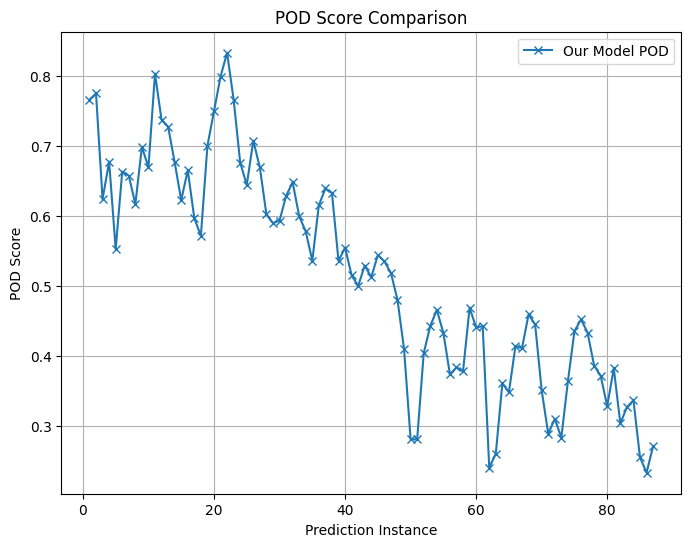

In [10]:
# Plotting POD curve

plt.figure(figsize=(8, 6))
plt.plot(np.arange(1, len(ours_model_evaluation.pods) + 1), ours_model_evaluation.pods, label='Our Model POD', marker='x')
plt.xlabel('Prediction Instance')
plt.ylabel('POD Score')
plt.title('POD Score Comparison')
plt.legend()
plt.grid()
plt.show()

In [19]:
# Print merging tracks
merging_tracks = [track for track in model.tracker.tracks if track.merged_to is not None]
print("Total merging tracks:", len(merging_tracks))

# Print splitting tracks
splitting_tracks = [track for track in model.tracker.tracks if track.splitted_from is not None]
print("Total splitting tracks:", len(splitting_tracks))

Total merging tracks: 173
Total splitting tracks: 164


Frame with most merging events: 2023-08-12 01:28:23 and merging count: 8


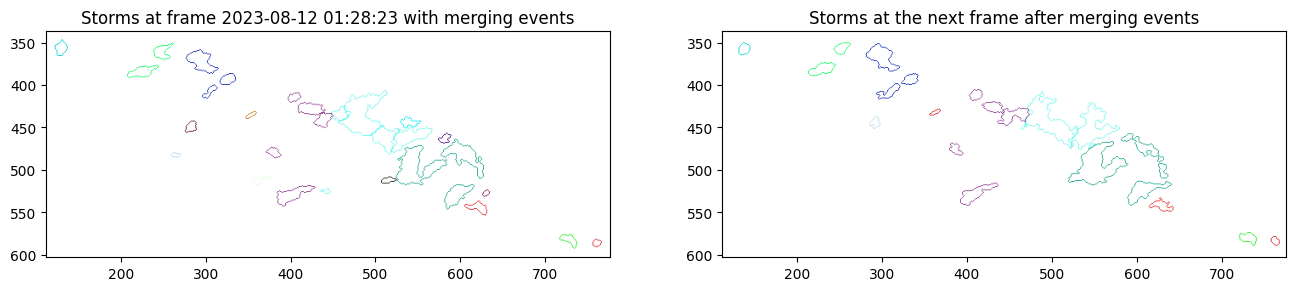

In [54]:
from src.preprocessing import convert_polygons_to_contours

# Count the frame that have the most merging events
merging_frames = [list(track.storms.keys())[-1] for track in merging_tracks]
most_merging_frame = max(set(merging_frames), key=merging_frames.count)
print(f"Frame with most merging events: {most_merging_frame} and merging count: {merging_frames.count(most_merging_frame)}")

idx = [idx for idx, (_, time_frame) in enumerate(dbz_maps) if time_frame == most_merging_frame][0]

plt.figure(figsize=(16, 10))
ys, xs = np.where(storms_maps[idx].dbz_map > 35)

img_shape = dbz_maps[0][0].shape

blank_img = np.ones(shape=(img_shape[0], img_shape[1], 3), dtype=np.uint8) * 255
plt.subplot(1, 2, 1)
for storm in storms_maps[idx].storms:
    contour = convert_polygons_to_contours([storm.contour])[0]
    cv2.drawContours(blank_img, [contour], -1, color=storm.contour_color, thickness=1)

plt.title(f"Storms at frame {most_merging_frame} with merging events")
plt.imshow(blank_img)

# Tight the x and y limits to the storm areas
plt.xlim(xs.min() - 10, xs.max() + 10)
plt.ylim(ys.max() + 10, ys.min() - 10)

blank_img = np.ones(shape=(img_shape[0], img_shape[1], 3), dtype=np.uint8) * 255
plt.subplot(1, 2, 2)
for storm in storms_maps[idx+1].storms:
    contour = convert_polygons_to_contours([storm.contour])[0]
    cv2.drawContours(blank_img, [contour], -1, color=storm.contour_color, thickness=1)

plt.title(f"Storms at the next frame after merging events")
plt.imshow(blank_img)

# Tight the x and y limits to the storm areas
plt.xlim(xs.min() - 10, xs.max() + 10)
plt.ylim(ys.max() + 10, ys.min() - 10)

plt.show()